## `bernet` tutorial

This notebook is a tutorial for a unidimensional representation using bernstein based neural network.

### 1. Import packages
---

In [1]:
import matplotlib.pyplot as plt
import torch

from bernet import Bernstein
from bernet import Direction, Head
from bernet import insert, select

torch.manual_seed(0)

### 2. Define parameters
---

In [2]:
num_points = 200

# Head
input_dim = 3
output_dim = 2

# Boundary condition
phi_0 = torch.zeros(num_points)
phi_1 = torch.ones(num_points)
dphi_dxi_1 = torch.zeros(num_points)

# Define parametric direction
xi = torch.linspace(0, 1, num_points)

# Latent space
latent = torch.randn(1, input_dim).expand(num_points, -1)

### 3. Boundary condition enforcement
---

Define model and direction

In [3]:
# Define model
model = Bernstein(
    heads=[
        Head(
            input_dim=input_dim,
            output_dim=output_dim,
        ),
    ],
)

# Define direction input
direction = Direction(
    latent=latent,
    xi=xi,
    phi_0=phi_0,
    phi_1=phi_1,
    dphi_dxi_1=dphi_dxi_1,
)

Compute output and create control points for visualization

In [4]:
with torch.no_grad():
    # Compute output
    phi = model.forward([direction])

    # Recreate the control points tensor for visualization (same logic as
    # `Bernstein.forward`'s Steps 1-3, for this single direction): Head ->
    # free points, then boundary injection. dim 0 is batch, dim 1 is this
    # direction's control-point axis.
    control_points = model.networks[0](direction.latent)

    n = control_points.shape[1] - 1
    n += sum(
        x is not None for x in (
            direction.phi_0, direction.phi_1,
            direction.dphi_dxi_0, direction.dphi_dxi_1,
        )
    )
    view_shape = (control_points.shape[0],) + (1,) * (control_points.ndim - 2)

    if direction.phi_0 is not None:
        control_points = insert(control_points, 1, 0)
        select(control_points, 1, 0).mul_(direction.phi_0.view(view_shape))

    if direction.phi_1 is not None:
        control_points = insert(control_points, 1, control_points.shape[1])
        select(control_points, 1, control_points.shape[1] - 1).mul_(direction.phi_1.view(view_shape))

    if direction.dphi_dxi_0 is not None:
        p_0 = select(control_points, 1, 0)
        control_points = insert(control_points, 1, 1)
        select(control_points, 1, 1).copy_(p_0 + direction.dphi_dxi_0.view(view_shape) / n)

    if direction.dphi_dxi_1 is not None:
        p_n = select(control_points, 1, control_points.shape[1] - 1)
        insert_at = control_points.shape[1] - 1
        control_points = insert(control_points, 1, insert_at)
        select(control_points, 1, insert_at).copy_(p_n - direction.dphi_dxi_1.view(view_shape) / n)

Plot curve and control points

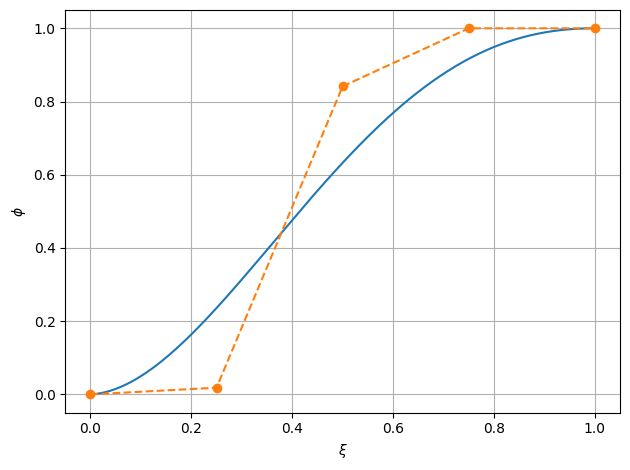

In [5]:
plt.figure()

# Plot curve
plt.plot(xi, phi)

# Plot control points
n = control_points.shape[-1] - 1
control_xi = torch.linspace(0, 1, n + 1)
control_polygon = control_points[0]

plt.plot(control_xi, control_polygon, "o--")

plt.ylabel(r"$\phi$")
plt.xlabel(r"$\xi$")

plt.grid()
plt.tight_layout()
plt.show()